# 전기차 에너지 소비 예측과 운행 추천

이 노트북은 추천 결과만 출력하지 않습니다. 데이터 품질, 시각화 근거, 모델 비교, 모델 선택, 오차 분석, 최종 평가와 추천까지의 판단 과정을 기록합니다.

- 적용 범위: 현재 CSV가 나타내는 단일 차종
- 예측 대상: 소비율 energy_consumption_kwhper100km, 단위 kWh/100km
- 성공 기준: 테스트 MAE 1.5 이하
- 운영 입력 가정: 거리, 외기 온도, 지도 API의 기준 예상 시간

## 1. 실행 환경과 데이터 불러오기

노트북은 notebooks 폴더에서 실행됩니다. 먼저 프로젝트 루트를 Python import 경로에 넣어 ev_energy 패키지를 찾을 수 있게 합니다.

In [1]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / 'ev_energy').exists() else NOTEBOOK_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ev_energy.data import BASIC_FEATURES, EXPANDED_FEATURES, TARGET, load_ev_data, split_ev_data
from ev_energy.analysis import data_quality_summary, plot_binned_boxplot, plot_distribution, plot_feature_relationship, plot_missing_values, plot_speed_temperature_heatmap
import importlib
import ev_energy.modeling as modeling
importlib.reload(modeling)
from ev_energy.modeling import cv_leaderboard, evaluate_regressor, select_model, select_stable_configuration, train_regressor, tune_random_forest
from ev_energy.recommendation import recommend_trip

frame = load_ev_data(PROJECT_ROOT / 'datas_ml' / 'ev_energy_consumption.csv')
print(f'데이터 크기: {frame.shape[0]:,}행 x {frame.shape[1]}열')

데이터 크기: 8,000행 x 10열


## 2. 데이터 품질 검토

학습 전에 결측치, 중복 행, 변수 범위를 확인합니다. 박스플롯 밖의 값은 자동 삭제하지 않습니다. 오류인지 실제 운행 조건인지 먼저 분석해야 하기 때문입니다.

완전 중복 행 수: 0


,missing_count,min,median,mean,max,std
speed_kmh,0,20.00,74.2000,74.427013,130.0,31.789245
payload_kg,0,0.00,246.8500,248.822563,500.0,144.327869
ambient_temp_C,0,-10.00,15.8000,15.587013,40.0,14.396150
hvac_power_kw,0,0.00,2.4800,2.477026,5.0,1.435208
road_grade_pct,0,-5.00,1.5000,1.464087,8.0,3.744704
battery_temp_C,0,15.00,29.9000,29.970725,45.0,8.717058
driving_style_index,0,0.00,0.5020,0.499641,1.0,0.286885
tire_pressure_bar,0,2.00,2.4000,2.401016,2.8,0.230790
trip_distance_km,0,5.10,103.2500,102.692337,200.0,55.844911
energy_consumption_kwhper100km,0,11.62,24.0925,24.137613,35.0,3.738082


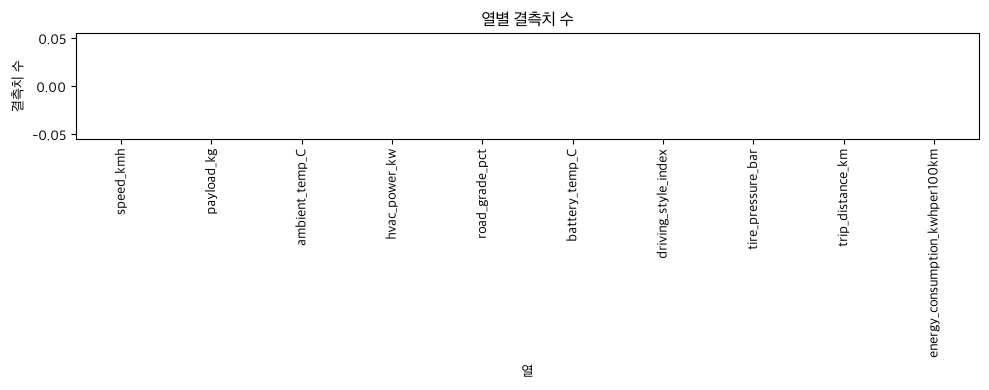

In [2]:
quality = data_quality_summary(frame)
print(f'완전 중복 행 수: {frame.duplicated().sum():,}')
display(quality)
plot_missing_values(frame);

## 3. 소비율 분포와 입력 변수 범위

소비율이 어느 구간에 모이는지 확인하고, 추천 후보가 학습 데이터에서 실제로 관측된 범위를 벗어나지 않게 할 근거를 만듭니다.

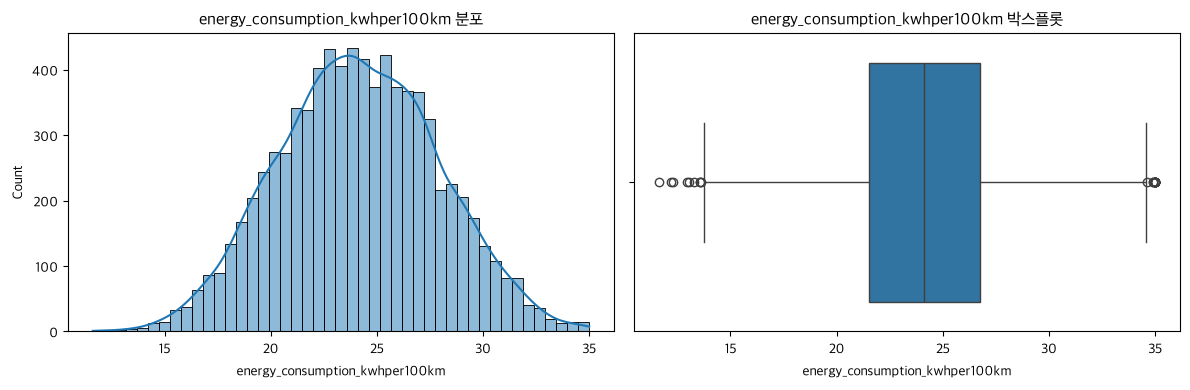

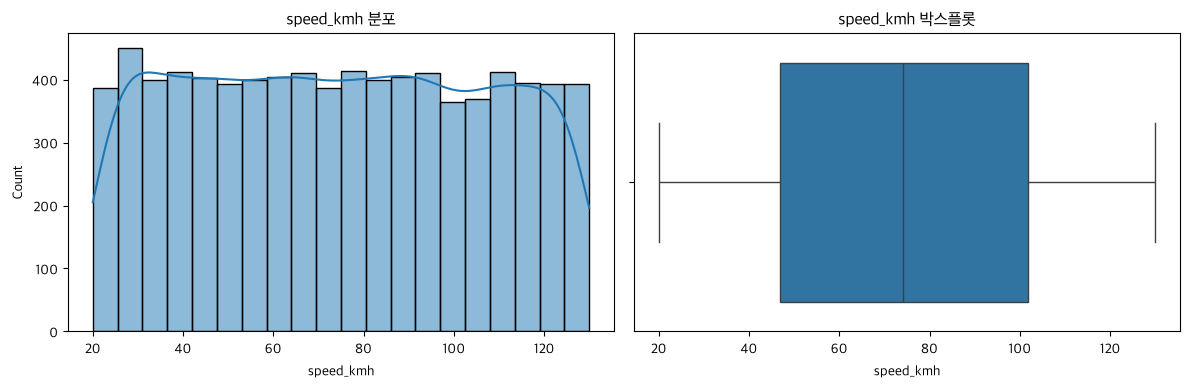

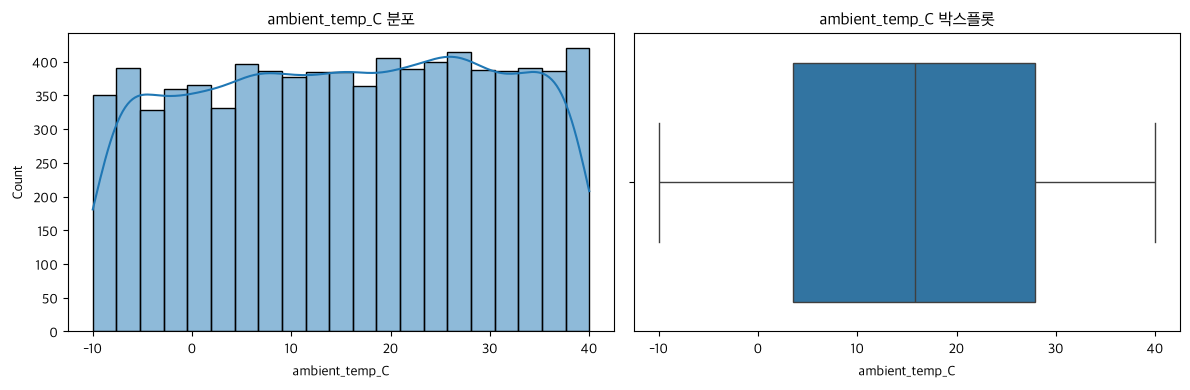

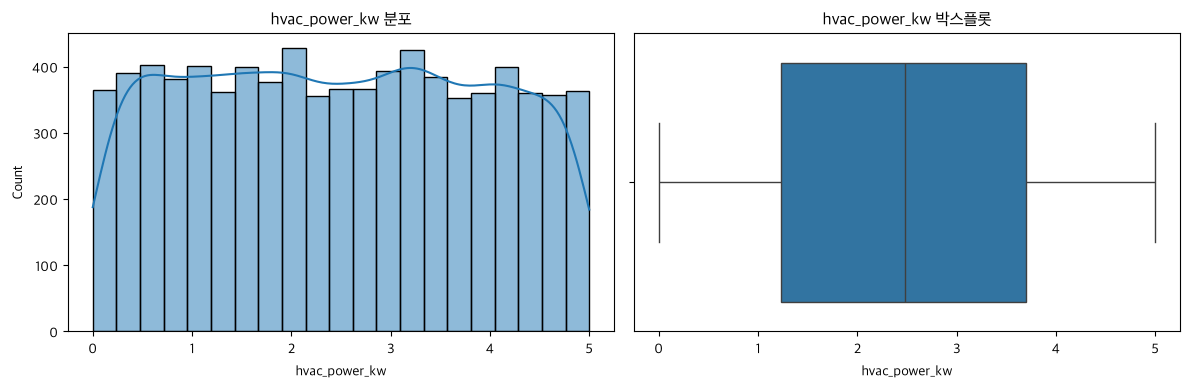

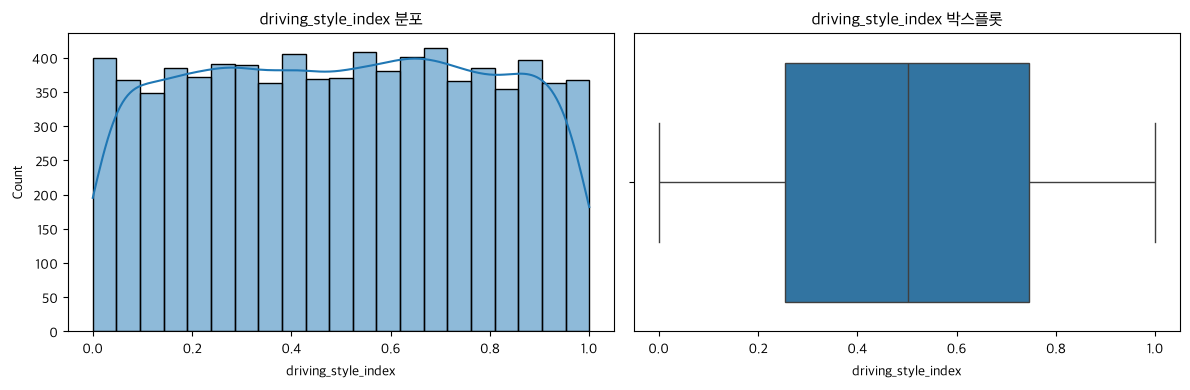

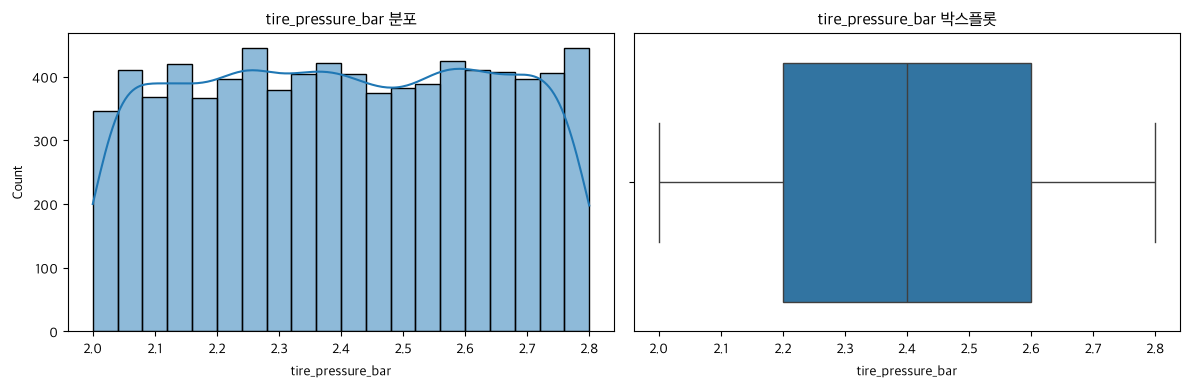

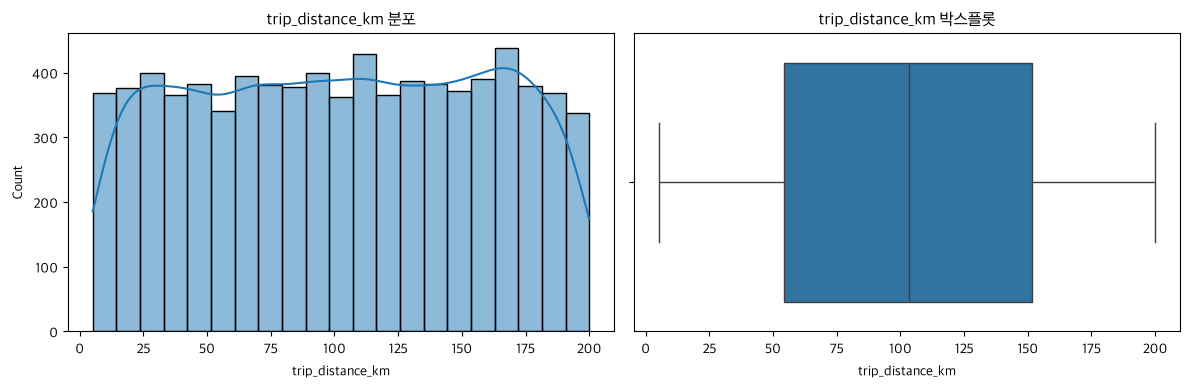

In [3]:
plot_distribution(frame, TARGET);
for column in ['speed_kmh', 'ambient_temp_C', 'hvac_power_kw', 'driving_style_index', 'tire_pressure_bar', 'trip_distance_km']:
    plot_distribution(frame, column);

## 4. 소비율을 설명하는 패턴

여기서는 속도, 온도, HVAC 출력, 거리의 관계를 확인합니다. 산점도 추세선은 패턴 탐색용이며 인과관계 결론은 아닙니다. 운전 성향과 공기압은 구간별 분포로 비교합니다.

,energy_consumption_kwhper100km,speed_kmh,ambient_temp_C,hvac_power_kw,driving_style_index,tire_pressure_bar,trip_distance_km,payload_kg,battery_temp_C,road_grade_pct
energy_consumption_kwhper100km,1.00,0.45,-0.16,0.37,0.26,-0.10,0.17,0.47,-0.09,0.50
speed_kmh,0.45,1.00,0.01,0.01,0.00,0.01,0.03,-0.00,-0.01,0.01
ambient_temp_C,-0.16,0.01,1.00,-0.01,0.03,0.01,-0.01,-0.00,-0.01,0.00
hvac_power_kw,0.37,0.01,-0.01,1.00,0.02,-0.01,-0.00,0.00,-0.01,0.02
driving_style_index,0.26,0.00,0.03,0.02,1.00,0.02,-0.01,-0.00,0.01,-0.02
tire_pressure_bar,-0.10,0.01,0.01,-0.01,0.02,1.00,-0.01,0.00,0.00,-0.02
trip_distance_km,0.17,0.03,-0.01,-0.00,-0.01,-0.01,1.00,0.01,-0.01,0.00
payload_kg,0.47,-0.00,-0.00,0.00,-0.00,0.00,0.01,1.00,0.00,0.01
battery_temp_C,-0.09,-0.01,-0.01,-0.01,0.01,0.00,-0.01,0.00,1.00,-0.03
road_grade_pct,0.50,0.01,0.00,0.02,-0.02,-0.02,0.00,0.01,-0.03,1.00


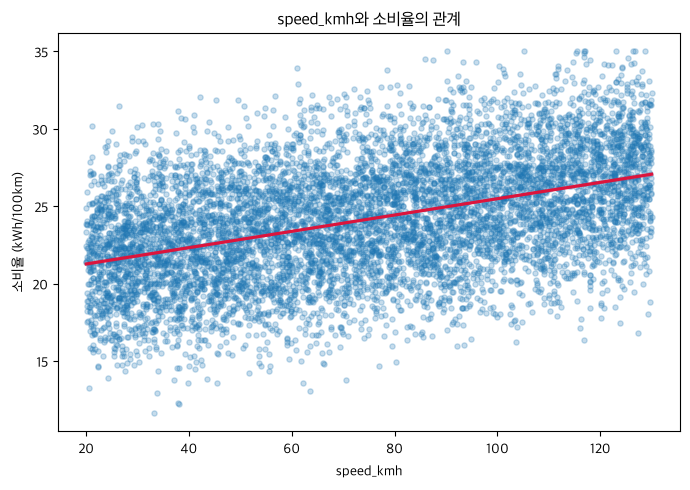

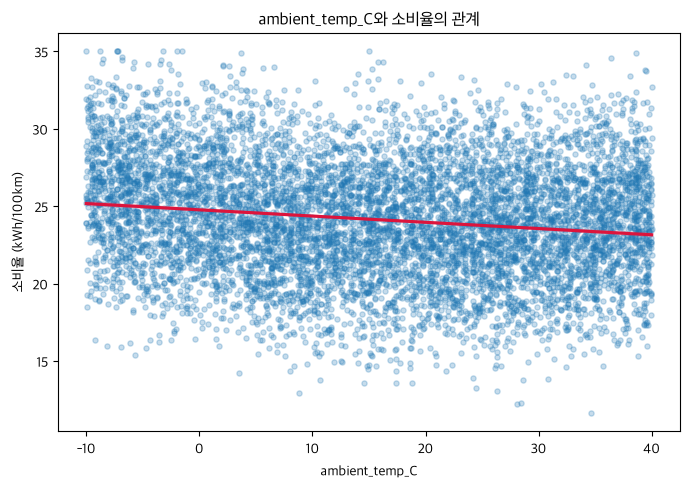

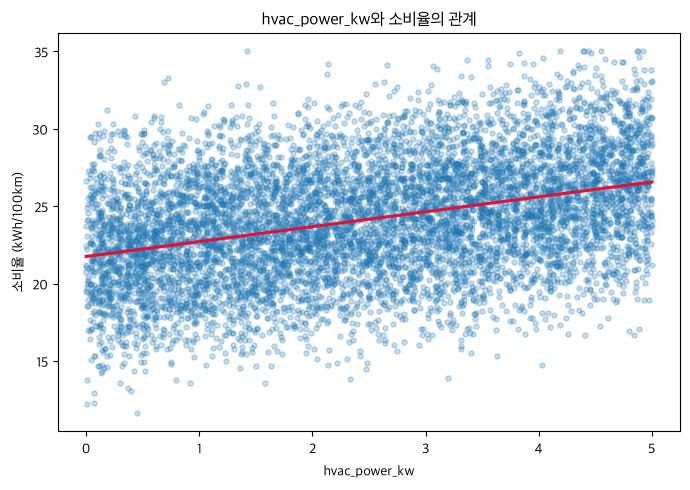

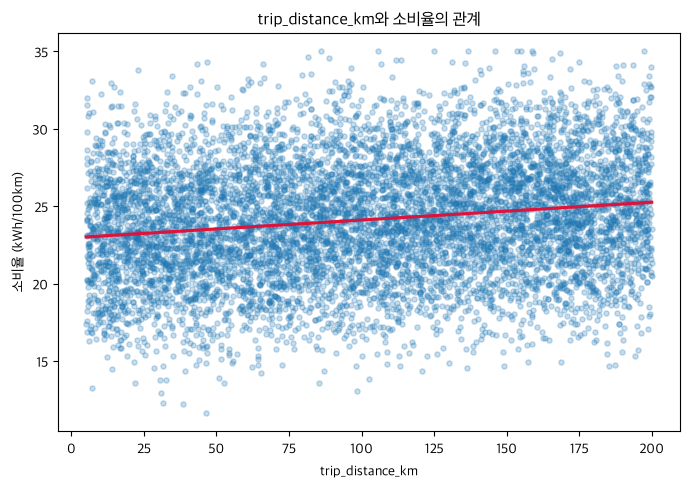

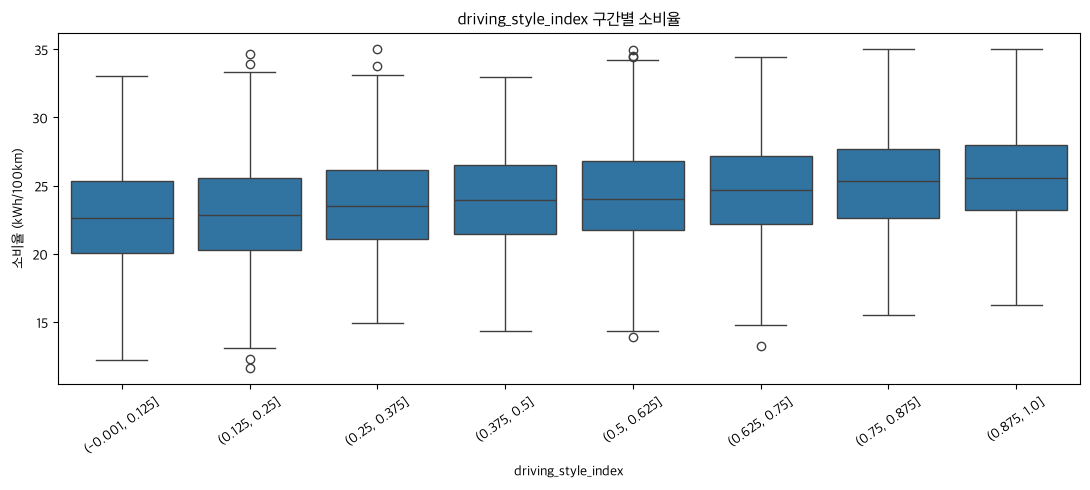

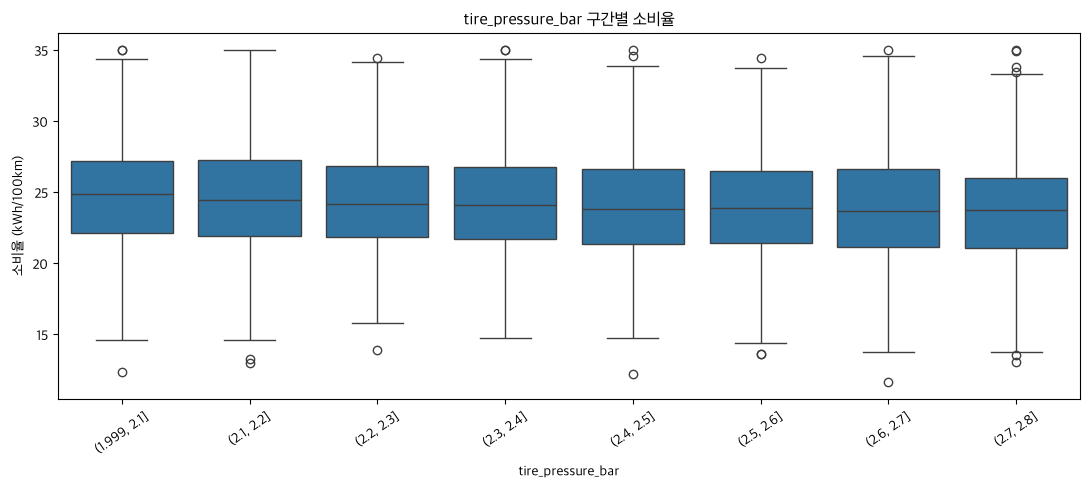

In [4]:
for feature in ['speed_kmh', 'ambient_temp_C', 'hvac_power_kw', 'trip_distance_km']:
    plot_feature_relationship(frame, feature);
plot_binned_boxplot(frame, 'driving_style_index');
plot_binned_boxplot(frame, 'tire_pressure_bar');
display(frame[[TARGET, *EXPANDED_FEATURES, 'road_grade_pct']].corr(numeric_only=True).round(2))

## 5. 속도와 온도의 상호작용

속도와 온도는 함께 소비율을 바꿀 수 있습니다. 히트맵의 색은 평균 소비율이고 각 칸의 숫자는 표본 수입니다. 표본 수 20 미만의 칸은 숨겨 우연한 평균을 과대 해석하지 않습니다.

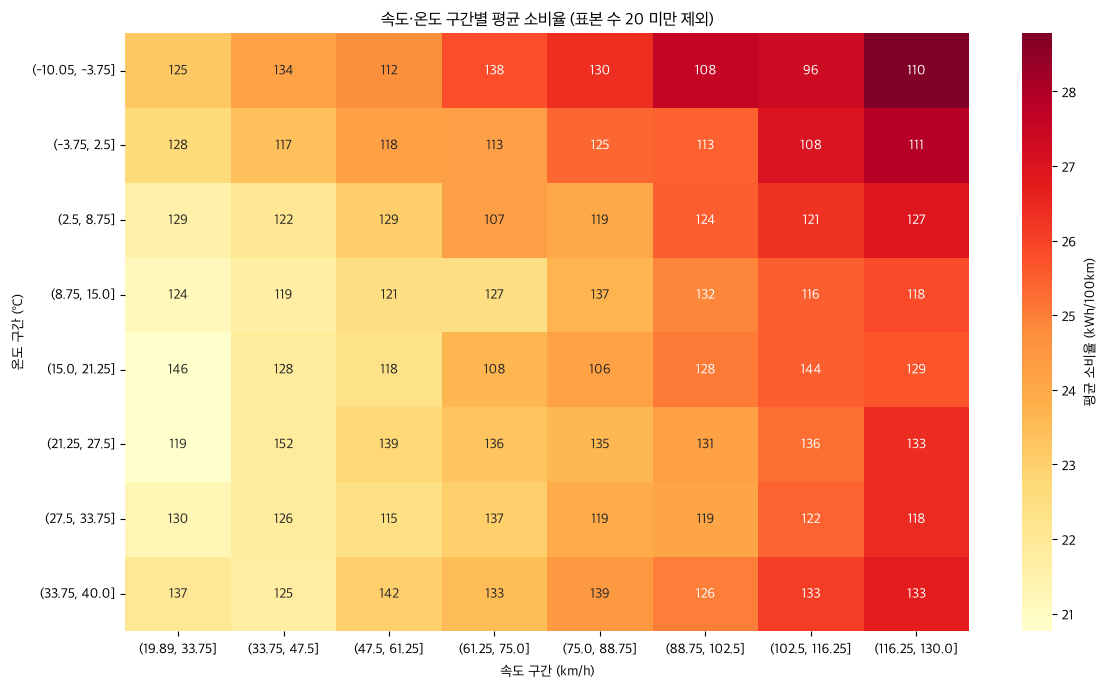

In [5]:
plot_speed_temperature_heatmap(frame, min_count=20);

## 6. 실험 설계와 모델 비교

데이터는 훈련 70%, 검증 15%, 테스트 15%로 나눕니다. 훈련 데이터는 학습에, 검증 데이터는 모델 선택에, 테스트 데이터는 최종 성적 확인에만 사용합니다.

가설은 적재량과 배터리 온도를 포함한 확장 모델이 기본 모델보다 정확할 수 있다는 것입니다. 기준선은 모든 상황에서 평균 소비율만 예측합니다.

In [6]:
train, validation, test = split_ev_data(frame, random_state=42)
print(f'훈련 {len(train):,}, 검증 {len(validation):,}, 테스트 {len(test):,}')
print('기본 모델 입력:', BASIC_FEATURES)
print('확장 모델 추가 입력:', sorted(set(EXPANDED_FEATURES) - set(BASIC_FEATURES)))

result = select_model(train, validation, test)
display(result['validation_metrics'].round(3))
print(f"검증 MAE 기준 선택 모델: {result['selected_name']}")
print('선택 모델 입력:', result['features'])

훈련 5,600, 검증 1,200, 테스트 1,200
기본 모델 입력: ['speed_kmh', 'ambient_temp_C', 'hvac_power_kw', 'driving_style_index', 'tire_pressure_bar', 'trip_distance_km']
확장 모델 추가 입력: ['battery_temp_C', 'payload_kg']


,mae,rmse,r2
기준선,3.001,3.667,-0.000
기본 모델,2.221,2.755,0.435
확장 모델,1.773,2.141,0.659


검증 MAE 기준 선택 모델: 확장 모델
선택 모델 입력: ['speed_kmh', 'ambient_temp_C', 'hvac_power_kw', 'driving_style_index', 'tire_pressure_bar', 'trip_distance_km', 'payload_kg', 'battery_temp_C']


### 모델 선택의 설득 근거

현재 분할에서는 기준선 검증 MAE가 약 3.001, 기본 모델이 약 2.221, 확장 모델이 약 1.773입니다. 확장 모델은 기본 모델보다 약 0.448 낮은 오차를 보이므로 선택합니다. 이 차이는 적재량과 배터리 온도가 소비율 설명에 도움이 된다는 근거입니다.

다만 이 두 값은 차량 센서나 프로필이 있어야 실제 서비스에 쓸 수 있습니다. 정확도와 입력 가능성 사이의 이 선택을 노트북에서 명시합니다.

## 7. 어떤 조건에서 모델이 약한가

전체 MAE 하나만으로는 모델의 약점을 알 수 없습니다. 속도와 온도 구간별 MAE를 계산해 불확실성을 크게 표시해야 할 조건을 찾습니다.

In [7]:
import pandas as pd
validation_check = validation[['speed_kmh', 'ambient_temp_C', TARGET]].copy()
validation_check['predicted'] = result['model'].predict(validation[result['features']])
validation_check['absolute_error'] = (validation_check[TARGET] - validation_check['predicted']).abs()
validation_check['speed_bin'] = pd.cut(validation_check['speed_kmh'], bins=6)
validation_check['temp_bin'] = pd.cut(validation_check['ambient_temp_C'], bins=6)

speed_error = validation_check.groupby('speed_bin', observed=True)['absolute_error'].agg(['mean', 'count']).rename(columns={'mean': 'MAE'})
temp_error = validation_check.groupby('temp_bin', observed=True)['absolute_error'].agg(['mean', 'count']).rename(columns={'mean': 'MAE'})
display(speed_error.round(3))
display(temp_error.round(3))

,MAE,count
speed_bin,,
"(20.09, 38.483]",1.749,211
"(38.483, 56.767]",1.770,199
"(56.767, 75.05]",1.726,194
"(75.05, 93.333]",1.825,202
"(93.333, 111.617]",1.880,196
"(111.617, 129.9]",1.686,198


,MAE,count
temp_bin,,
"(-10.05, -1.667]",1.743,214
"(-1.667, 6.667]",1.629,194
"(6.667, 15.0]",1.968,187
"(15.0, 23.333]",1.922,184
"(23.333, 31.667]",1.795,206
"(31.667, 40.0]",1.612,215


## 8. 경사도 제외가 정확도에 미치는 영향

경사도는 이 데이터에서 유용한 정보일 수 있지만, 초기 서비스에서 정확하고 일관되게 입력하기 어려워 운영 모델에서는 제외했습니다. 아래 실험은 경사도를 운영 모델에 넣기 위한 것이 아니라, 목표 MAE에 미달하는 원인을 찾는 진단입니다.

In [8]:
grade_features = [*EXPANDED_FEATURES, 'road_grade_pct']
grade_diagnostic_model = train_regressor(train, grade_features)
grade_diagnostic_metrics = evaluate_regressor(grade_diagnostic_model, validation, grade_features)
grade_comparison = pd.DataFrame({
    '운영 후보: 경사도 제외': result['validation_metrics'].loc['확장 모델'],
    '진단 전용: 경사도 포함': grade_diagnostic_metrics,
}).T
display(grade_comparison.round(3))

,mae,rmse,r2
운영 후보: 경사도 제외,1.773,2.141,0.659
진단 전용: 경사도 포함,0.928,1.175,0.897


현재 데이터에서 경사도 제외 확장 모델의 검증 MAE는 약 1.773, 경사도 포함 진단 모델은 약 0.928입니다. 목표 미달의 주된 원인은 모델 설정보다 제외한 경사도 정보입니다.

결론은 경사도를 억지로 운영 모델에 넣자는 뜻이 아닙니다. 현재 추천은 불확실성을 표시하고, 추후 신뢰할 수 있는 경로 고도 API를 확보하면 개선 여지가 크다는 뜻입니다.

## 9. 최종 테스트 평가

모델 선택이 끝난 뒤 테스트 데이터에서 한 번만 최종 성능을 확인합니다. 목표 MAE와 비교해 결과를 정직하게 기록합니다.

In [9]:
test_metrics = pd.Series(result['test_metrics'], name='테스트 결과').round(3)
display(test_metrics.to_frame())
if result['test_metrics']['mae'] <= 1.5:
    print('판정: 목표 MAE 1.5를 충족했습니다.')
else:
    print('판정: 목표 MAE 1.5에 미달했습니다. 경사도 제외에 따른 정보 손실을 개선 과제로 남깁니다.')

,테스트 결과
mae,1.720
rmse,2.085
r2,0.675


판정: 목표 MAE 1.5에 미달했습니다. 경사도 제외에 따른 정보 손실을 개선 과제로 남깁니다.


## 10. 균형 모드 추천

선택된 모델에 속도, HVAC, 운전 성향, 공기압 후보를 넣어 봅니다. balanced 모드는 기준 시간보다 최대 10% 증가한 후보만 남기고, 그중 예상 총소비량이 가장 낮은 계획을 선택합니다.

saving_is_confident가 거짓이면 예상 절감량이 모델 오차 범위 안일 수 있으므로 사용자에게 절감 효과를 단정하지 않습니다.

In [10]:
recommendation = recommend_trip(
    result['model'], train,
    trip_distance_km=120.0, ambient_temp_C=15.0, base_trip_minutes=90.0,
    profile={'hvac_power_kw': 3.5, 'driving_style_index': 0.75, 'tire_pressure_bar': 2.4},
    mode='balanced', manufacturer_tire_range=(2.3, 2.7),
    model_mae=result['test_metrics']['mae'], features=result['features'],
)
pd.Series(recommendation).to_frame('균형 모드 추천 결과')

,균형 모드 추천 결과
mode,balanced
speed_kmh,75.0
hvac_power_kw,0.0
driving_style_index,0.0
tire_pressure_bar,2.7
estimated_trip_minutes,96.0
additional_minutes,6.0
current_consumption_kwhper100km,26.509385
recommended_consumption_kwhper100km,20.008612
current_total_energy_kwh,31.811262


## 11. 결론과 다음 개선

1. 적재량과 배터리 온도를 포함한 확장 모델이 기본 모델보다 낮은 검증 오차를 보였습니다.
2. 경사도는 큰 정보 가치를 보이지만 현재 서비스 입력의 신뢰성 때문에 제외했습니다.
3. 현재 추천은 절감량과 함께 불확실성 표시를 제공해야 합니다.
4. 다음 개선 순서는 기본 입력만으로 Random Forest 설정을 교차 검증하고, 그 결과를 기준으로 다른 회귀 모델과 비교하는 것입니다.

## 12. 좋은 Random Forest 설정 찾기

운영 모델은 센서가 필요하지 않은 기본 입력 6개만 사용합니다. GridSearchCV는 훈련 데이터 안에서 5-fold 교차 검증을 수행해 54개 설정의 평균 MAE와 MAE 표준편차를 계산합니다.

평균 MAE가 최저값에서 0.05 이내인 설정은 같은 성능권으로 보고, 그중 표준편차가 가장 작은 설정을 선택합니다. 따라서 한 번의 우연한 데이터 분할에만 좋은 모델을 피할 수 있습니다.

In [11]:
from ev_energy.modeling import cv_leaderboard, select_stable_configuration, tune_random_forest

rf_search = tune_random_forest(train, features=BASIC_FEATURES)
rf_ranking = cv_leaderboard(rf_search)
display(rf_ranking.head(10))

stable_configuration = select_stable_configuration(rf_ranking, mae_tolerance=0.05)
display(stable_configuration.to_frame('선택된 안정 설정'))

,mean_mae,std_mae,param_max_depth,param_max_features,param_min_samples_leaf,param_n_estimators
0,2.264240,0.021443,10,0.7,5,600
1,2.265759,0.020667,10,0.7,5,200
2,2.265987,0.020575,10,0.7,5,400
3,2.267362,0.022838,10,0.7,3,600
4,2.267804,0.021291,20,0.7,5,600
5,2.267822,0.021223,None,0.7,5,600
6,2.269074,0.022201,10,0.7,3,400
7,2.269286,0.021987,None,0.7,5,400
8,2.269314,0.022036,20,0.7,5,400
9,2.269587,0.021764,10,0.7,1,600


,선택된 안정 설정
mean_mae,2.298496
std_mae,0.013907
param_max_depth,20
param_max_features,1.0
param_min_samples_leaf,1
param_n_estimators,200


In [ ]:
rf_search = tune_random_forest(train, features=BASIC_FEATURES)


### 순위표 읽는 법

- mean_mae: 5개 검증 분할에서의 평균 오차, 작을수록 좋음
- std_mae: 분할에 따른 MAE의 흔들림, 작을수록 안정적
- param_으로 시작하는 열: 해당 모델 설정값

선택된 안정 설정은 절대 최저 mean_mae와 달라질 수 있습니다. 최저값과 0.05 이내라면, 약간의 평균 오차 차이보다 운영에서의 안정성을 우선하기 때문입니다.

## 13. 선택된 설정으로 검증·테스트 평가

GridSearchCV의 기본 best_estimator는 평균 MAE 최저 설정입니다. 여기서는 안정성 규칙으로 고른 설정을 새 모델에 적용해 다시 학습합니다. 검증 데이터에서 성능을 확인한 뒤, 테스트 데이터에서는 마지막으로 한 번만 평가합니다.

In [12]:
from sklearn.ensemble import RandomForestRegressor

stable_params = {
    column.removeprefix('param_'): value
    for column, value in stable_configuration.items()
    if column.startswith('param_')
}
tuned_model = RandomForestRegressor(random_state=42, n_jobs=-1, **stable_params)
tuned_model.fit(train[BASIC_FEATURES], train[TARGET])

tuned_validation_metrics = evaluate_regressor(tuned_model, validation, BASIC_FEATURES)
tuned_test_metrics = evaluate_regressor(tuned_model, test, BASIC_FEATURES)
display(pd.DataFrame({
    '기존 기본 모델 검증': result['validation_metrics'].loc['기본 모델'],
    '튜닝 모델 검증': tuned_validation_metrics,
    '튜닝 모델 테스트': tuned_test_metrics,
}).T.round(3))

,mae,rmse,r2
기존 기본 모델 검증,2.221,2.755,0.435
튜닝 모델 검증,2.236,2.776,0.427
튜닝 모델 테스트,2.273,2.793,0.416


## 14. 기본 입력 튜닝 모델로 추천하기

이제 추천에는 센서 입력이 필요한 확장 모델 대신, 튜닝된 기본 입력 모델을 사용합니다. 현재 계획의 HVAC, 운전 성향, 공기압은 사용자 입력이 아니라 앞에서 합의한 기본값입니다.

In [13]:
tuned_recommendation = recommend_trip(
    tuned_model, train,
    trip_distance_km=120.0, ambient_temp_C=15.0, base_trip_minutes=90.0,
    profile={'hvac_power_kw': 2.5, 'driving_style_index': 0.50, 'tire_pressure_bar': 2.4},
    mode='balanced', manufacturer_tire_range=(2.3, 2.7),
    model_mae=tuned_test_metrics['mae'], features=BASIC_FEATURES,
)
pd.Series(tuned_recommendation).to_frame('튜닝된 기본 모델 추천 결과')

,튜닝된 기본 모델 추천 결과
mode,balanced
speed_kmh,75.0
hvac_power_kw,0.5
driving_style_index,0.0
tire_pressure_bar,2.7
estimated_trip_minutes,96.0
additional_minutes,6.0
current_consumption_kwhper100km,24.397592
recommended_consumption_kwhper100km,18.913433
current_total_energy_kwh,29.27711


In [ ]:
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
)
from sklearn.model_selection import GridSearchCV, KFold, train_test_split


def evaluate_model(
    frame: pd.DataFrame,
    model,
    param_grid: dict,
    target: str,
    random_state: int = 42,
):
    X = frame.drop(columns=[target])
    y = frame[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=random_state,
    )

    splitter = KFold(
        n_splits=5,
        shuffle=True,
        random_state=random_state,
    )

    search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring="neg_mean_absolute_error",
        cv=splitter,
        n_jobs=-1,
        refit=True,
    )

    search.fit(X_train, y_train)

    # 최적 모델
    best_model = search.best_estimator_

    # Test 예측
    predicted = best_model.predict(X_test)

    # 결과 표
    result = pd.DataFrame([{
        "model": best_model.__class__.__name__,
        "cv_mae": -search.best_score_,
        "cv_r2": r2_score(y_train, -search.best_score_),
        "test_mae": mean_absolute_error(y_test, predicted),
        "test_rmse": root_mean_squared_error(y_test, predicted),
        "test_r2": r2_score(y_test, predicted),
        "best_params": search.best_params_,
    }])

    return search, result

In [37]:
from sklearn.ensemble import RandomForestRegressor

RANDOM_FOREST_PARAM_GRID = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 3, 5],
    "max_features": [0.7, 1.0],
}

rf_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,
)

rf_search, rf_result = evaluate_model(
    frame=frame,
    model=rf_model,
    param_grid=RANDOM_FOREST_PARAM_GRID,
    target="energy_consumption_kwhper100km",
)

display(rf_result.round(3))

/Users/sunub/workspace/python-lab/gg1th_ml_basic/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,model,cv_mae,test_mae,test_rmse,test_r2,best_params
0,RandomForestRegressor,0.98,0.926,1.154,0.901,"{'max_depth': 20, 'max_features': 0.7, 'min_sa..."


In [ ]:
from sklearn.linear_model import Ridge
from lightgbm import LGBMRegressor
from typing import Any

models: dict[str, Any] = {
    "Ridge": Ridge(),

    "RandomForest": RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
    ),

    "XGBoost": XGBRegressor(
        random_state=42,
        n_jobs=-1,
    ),

    "LightGBM": LGBMRegressor(
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ),
}

param_grids: dict[str, dict[str, list[Any]]] = {
    "Ridge": {
        "alpha": [0.1, 1, 10, 100],
    },

    "RandomForest": {
        "n_estimators": [200, 400],
        "max_depth": [None, 10, 20],
        "min_samples_leaf": [1, 3, 5],
    },

    "XGBoost": {
        "n_estimators": [300, 500],
        "max_depth": [3, 5],
        "learning_rate": [0.03, 0.1],
        "subsample": [0.8, 1.0],
    },

    "LightGBM": {
        "n_estimators": [300, 500],
        "num_leaves": [15, 31],
        "learning_rate": [0.03, 0.1],
        "max_depth": [-1, 10],
    },
}

In [44]:
results = []

for name, model in models.items():

    search, result_df = evaluate_model(
        frame=frame,
        model=model,
        param_grid=param_grids[name],
        target=TARGET,
    )

    # 모델 이름을 우리가 지정한 이름으로 변경
    result_df["model"] = name

    results.append(result_df)

comparison = (
    pd.concat(results, ignore_index=True)
    .sort_values("test_mae")
)

display(comparison.round(3))

,model,cv_mae,test_mae,test_rmse,test_r2,best_params
2,XGBoost,0.724,0.709,0.889,0.941,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
3,LightGBM,0.736,0.718,0.895,0.940,"{'learning_rate': 0.03, 'max_depth': -1, 'n_es..."
0,Ridge,0.807,0.807,1.005,0.925,{'alpha': 1}
1,RandomForest,0.985,0.931,1.163,0.899,"{'max_depth': 20, 'min_samples_leaf': 1, 'n_es..."
